### Flagging Vendor Invoices for Manual Review
##### **Objective**: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

- Manual invoice review is time-consuming and does not scale with transaction volume.

- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.

- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [135]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt 

In [136]:
conn = sqlite3.connect(r"C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\Machine Learning\Vendor Invoice ML Project\data\inventory.db")

tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [137]:
from IPython.display import display

for table in tables['name']:
    print("\nTable:", table)
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
    df.columns = df.columns.str.lower()
    display(df)


Table: purchases


,inventoryid,store,brand,description,size,vendornumber,vendorname,ponumber,podate,receivingdate,invoicedate,paydate,purchaseprice,quantity,dollars,classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1



Table: purchase_prices


,brand,description,price,size,volume,classification,purchaseprice,vendornumber,vendorname
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.



Table: vendor_invoice


,vendornumber,vendorname,invoicedate,ponumber,podate,paydate,quantity,dollars,freight,approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None



Table: begin_inventory


,inventoryid,store,city,brand,description,size,onhand,price,startdate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01



Table: end_inventory


,inventoryid,store,city,brand,description,size,onhand,price,enddate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [138]:
purchase_agg_df = pd.read_sql_query("""
select
    ponumber,
    count(distinct brand) as total_brands,
    sum(quantity) as total_item_quantity,
    sum(dollars) as total_item_dollars,
    round(avg(julianday(receivingdate) - julianday(podate)),2) as avg_receiving_delay
from purchases
group by ponumber""", conn)

In [139]:
pd.read_sql_query("""
select
    quantity as invoice_quantity,
    dollars as invoice_dollars,
    freight,
    (julianday(invoicedate) - julianday(podate)) as days_po_to_invoice,
    (julianday(paydate) - julianday(invoicedate)) as days_to_pay
from  vendor_invoice""",conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [140]:
df = pd.read_sql_query("""
with purchase_agg as (
select
    p.ponumber,
    count(distinct p.brand) as total_brands,
    sum(p.quantity) as total_item_quantity,
    sum(p.dollars) as total_item_dollars,
    round(avg(julianday(p.receivingdate) - julianday(p.podate)),2) as avg_receiving_delay
from purchases p
group by p.ponumber
)

select
    vi.ponumber,
    vi.quantity as invoice_quantity,
    vi.dollars as invoice_dollars,
    vi.freight,
    (julianday(vi.invoicedate) - julianday(vi.podate)) as days_po_to_invoice,
    (julianday(vi.paydate) - julianday(vi.invoicedate)) as days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
from  vendor_invoice vi
left join purchase_agg pa
on vi.ponumber = pa.ponumber
""", conn)

In [141]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.00
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.33
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.00
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.61
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.75
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.87
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.05
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.00
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.05


In [142]:
df.isna().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [143]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [ ]:
def create_invoice_risk_label(row):

    #Invoice total mismatch with item-level total
    if abs(row['invoice_dollars'] - row['total_item_dollars']) > 5:
        return 1
    
    # Abnormally high receiving delay
    if row['avg_receiving_delay'] > 10:
        return 1
    
    return 0

df['flag_invoice'] = df.apply(create_invoice_risk_label, axis = 1)
df['flag_invoice'].value_counts()


flag_invoice
0    3695
1    1848
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

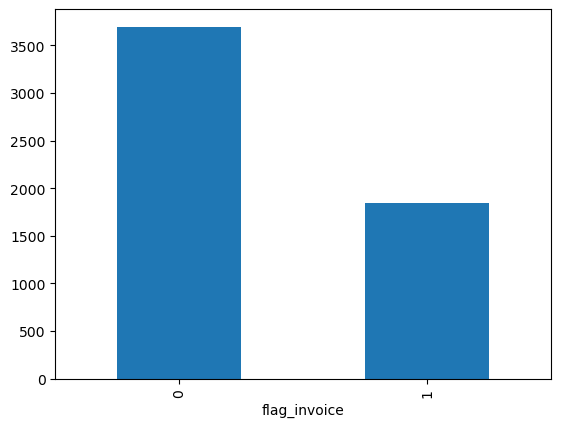

In [145]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

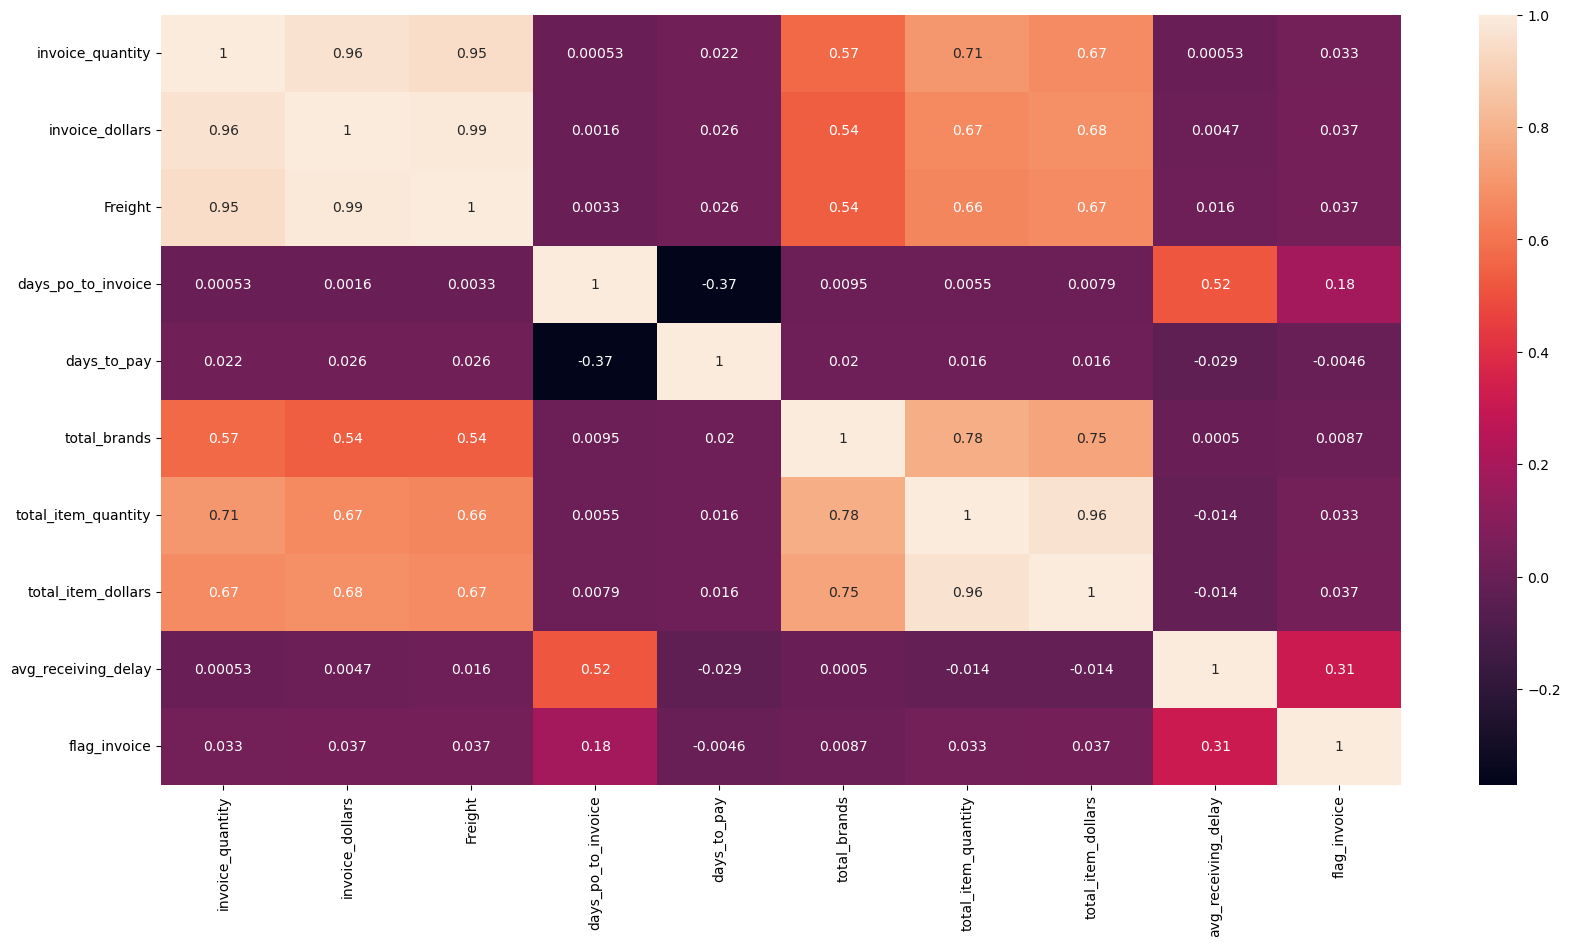

In [146]:
plt.figure(figsize = (20,10))
sns.heatmap(df.iloc[:,1:].corr(), annot = True)
plt.show()

In [147]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [148]:
significant_features = []
non_significant_features = []
results = []

In [149]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [150]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            'metric' : metric,
            'flagged_mean' : flagged_mean.round(2),
            'normal_mean' : normal_mean.round(2),
            'p value' : p_value.round(3)
        })
    else:
        non_significant_features.append(metric)


In [151]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [152]:
non_significant_features

['days_to_pay', 'total_brands']

In [153]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6723.52,
  'normal_mean': 5726.47,
  'p value': 0.022},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65506.23,
  'normal_mean': 54355.95,
  'p value': 0.009},
 {'metric': 'Freight',
  'flagged_mean': 333.51,
  'normal_mean': 277.17,
  'p value': 0.009},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6723.52,
  'normal_mean': 5726.47,
  'p value': 0.022},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65506.23,
  'normal_mean': 54355.95,
  'p value': 0.009},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p value': 0.0}]

In [154]:
X = df[['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','total_item_quantity','total_item_dollars','avg_receiving_delay']]
y = df['flag_invoice']
        

In [155]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [156]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4434, 7), (1109, 7), (4434,), (1109,))

#### StandardScaler

In [157]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [159]:
import warnings
warnings.filterwarnings('ignore')

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [160]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{model_name}")
    print("=" * 50)
    print(f"Accuracy:  {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1-Score:  {f1:.2f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [161]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test, y_test, 'Random Forest Classifier')


Logistic Regression
Accuracy:  0.74
Precision: 0.74
Recall:    0.38
F1-Score:  0.50

Confusion Matrix:
[[673  52]
 [237 147]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.38      0.50       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.66      1109
weighted avg       0.74      0.74      0.71      1109


Decision Tree Classifier
Accuracy:  0.35
Precision: 0.35
Recall:    1.00
F1-Score:  0.51

Confusion Matrix:
[[  0 725]
 [  0 384]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       725
           1       0.35      1.00      0.51       384

    accuracy                           0.35      1109
   macro avg       0.17      0.50      0.26      1109
weighted avg       0.12      0.35      0.18      1109


Random Forest Classifier
Accuracy:  0.

#### Min-Max Scaler

In [163]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test, y_test, 'Random Forest Classifier')


Logistic Regression
Accuracy:  0.65
Precision: 0.00
Recall:    0.00
F1-Score:  0.00

Confusion Matrix:
[[725   0]
 [384   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       725
           1       0.00      0.00      0.00       384

    accuracy                           0.65      1109
   macro avg       0.33      0.50      0.40      1109
weighted avg       0.43      0.65      0.52      1109


Decision Tree Classifier
Accuracy:  0.35
Precision: 0.35
Recall:    1.00
F1-Score:  0.51

Confusion Matrix:
[[  0 725]
 [  0 384]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       725
           1       0.35      1.00      0.51       384

    accuracy                           0.35      1109
   macro avg       0.17      0.50      0.26      1109
weighted avg       0.12      0.35      0.18      1109


Random Forest Classifier
Accuracy:  0.

In [164]:
model3.feature_importances_

array([0.11303962, 0.11128087, 0.10183927, 0.02533723, 0.14899459,
       0.20017855, 0.29932987])

In [166]:
feature_importance = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : model3.feature_importances_
}).sort_values(by = 'importance', ascending = False)

feature_importance

,feature,importance
6,avg_receiving_delay,0.299330
5,total_item_dollars,0.200179
4,total_item_quantity,0.148995
0,invoice_quantity,0.113040
1,invoice_dollars,0.111281
2,Freight,0.101839
3,days_po_to_invoice,0.025337


In [168]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars',]]
y = df['flag_invoice']

In [171]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

evaluate_model(model2, X_test, y_test, 'Decision Tree Classifier')


Decision Tree Classifier
Accuracy:  0.65
Precision: 0.33
Recall:    0.01
F1-Score:  0.02

Confusion Matrix:
[[719   6]
 [381   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.99      0.79       725
           1       0.33      0.01      0.02       384

    accuracy                           0.65      1109
   macro avg       0.49      0.50      0.40      1109
weighted avg       0.54      0.65      0.52      1109



In [176]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

param_grid = {
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2
)

grid_search.fit(X_train_scaled,y_train)

evaluate_model(grid_search, X_test_scaled, y_test, "Decision Tree Classifier")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3; total time=   0.0s
[CV] END criterion=gini, max_

In [182]:
from sklearn.metrics import confusion_matrix

confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[717,  41],
       [  8, 343]], dtype=int64)

In [183]:
confusion_matrix(model2.predict(X_test_scaled),y_test)

array([[634,  90],
       [ 91, 294]], dtype=int64)

In [184]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 2}